In [1]:
# Importando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Carregando o ranking final
df_final = pd.read_csv('../data/processed/ranking_final.csv', index_col=0)

# Configurações gerais de estilo dos gráficos
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Dados carregados com sucesso!")
print(f"Total de seleções: {len(df_final)}")
print(df_final[['country_full', 'pontuacao_final']].head(10))

✅ Dados carregados com sucesso!
Total de seleções: 48
   country_full  pontuacao_final
1     Argentina        88.658238
2        France        86.500050
3       England        76.399447
4       Morocco        76.063123
5         Japan        74.358007
6       Croatia        72.817570
7         Spain        72.780869
8      Portugal        72.232073
9       Belgium        71.994917
10       Brazil        69.986454


C:\Users\eduar\AppData\Local\Temp\ipykernel_78688\3391271626.py:32: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\eduar\AppData\Local\Temp\ipykernel_78688\3391271626.py:33: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('../images/top15_favoritos.png', dpi=150, bbox_inches='tight')
C:\Users\eduar\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


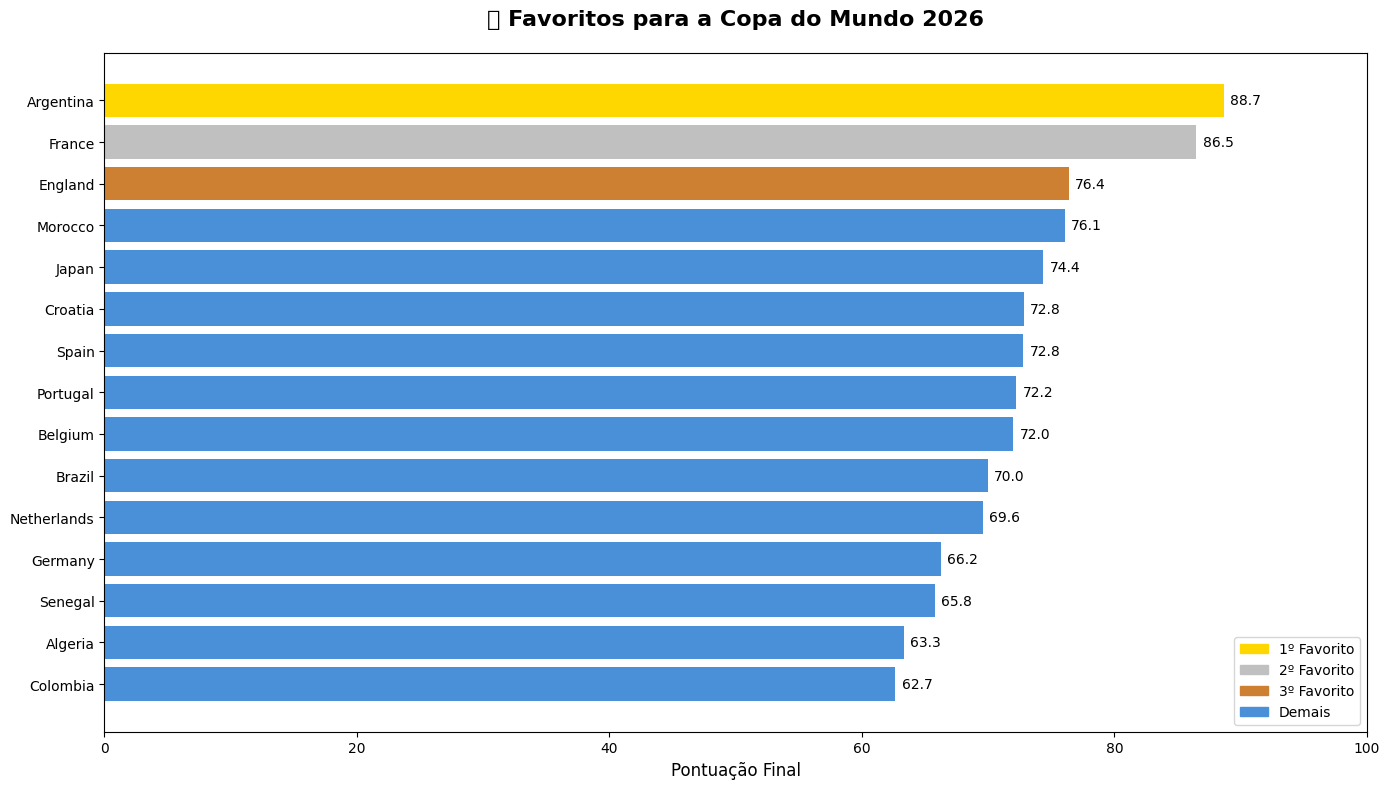

✅ Gráfico salvo em images/top15_favoritos.png


In [2]:
# Selecionando o top 15
top15 = df_final.head(15)

# Cores — destacando o top 3
cores = ['#FFD700', '#C0C0C0', '#CD7F32'] + ['#4A90D9'] * 12

# Criando o gráfico
fig, ax = plt.subplots(figsize=(14, 8))

barras = ax.barh(top15['country_full'][::-1], top15['pontuacao_final'][::-1], color=cores[::-1])

# Adicionando os valores nas barras
for barra in barras:
    largura = barra.get_width()
    ax.text(largura + 0.5, barra.get_y() + barra.get_height()/2,
            f'{largura:.1f}', va='center', fontsize=10)

# Títulos e labels
ax.set_title('🏆 Favoritos para a Copa do Mundo 2026', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Pontuação Final', fontsize=12)
ax.set_xlim(0, 100)

# Legenda
legenda = [
    mpatches.Patch(color='#FFD700', label='1º Favorito'),
    mpatches.Patch(color='#C0C0C0', label='2º Favorito'),
    mpatches.Patch(color='#CD7F32', label='3º Favorito'),
    mpatches.Patch(color='#4A90D9', label='Demais')
]
ax.legend(handles=legenda, loc='lower right')

plt.tight_layout()
plt.savefig('../images/top15_favoritos.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico salvo em images/top15_favoritos.png")

C:\Users\eduar\AppData\Local\Temp\ipykernel_78688\1759438161.py:35: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\eduar\AppData\Local\Temp\ipykernel_78688\1759438161.py:36: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.savefig('../images/radar_top5.png', dpi=150, bbox_inches='tight')
C:\Users\eduar\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


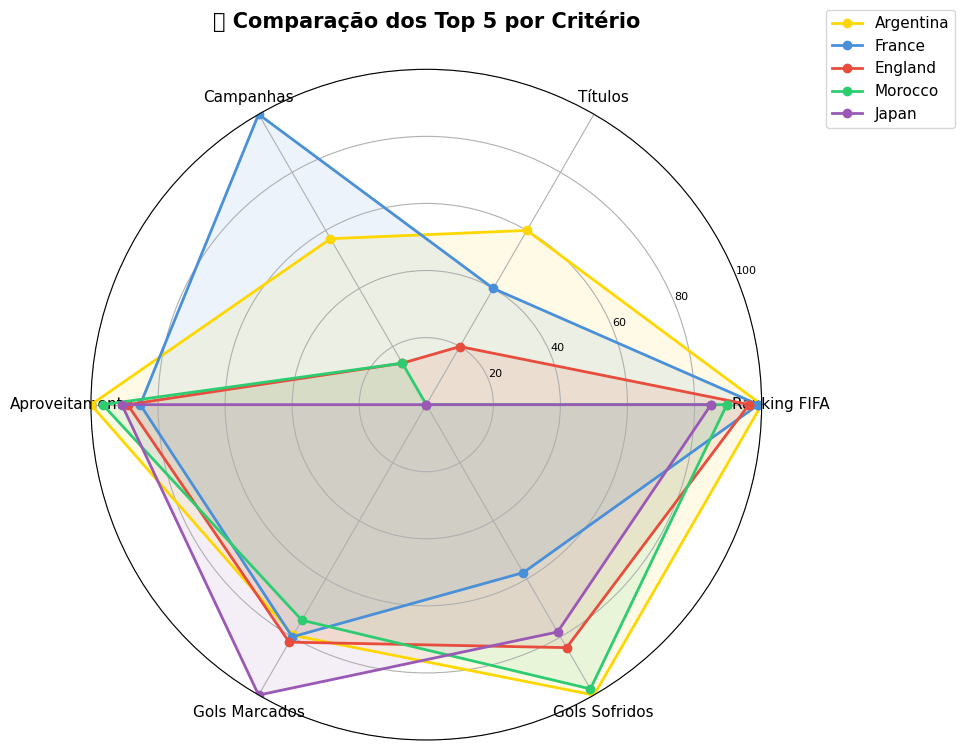

✅ Gráfico salvo em images/radar_top5.png


In [3]:
# Critérios e pesos para o radar
criterios = ['Ranking FIFA', 'Títulos', 'Campanhas', 'Aproveitamento', 'Gols Marcados', 'Gols Sofridos']
colunas = ['nota_ranking', 'nota_titulos', 'nota_campanha', 'nota_aproveitamento', 'nota_gols_marcados', 'nota_gols_sofridos']

# Top 5 seleções
top5 = df_final.head(5)

# Configurando o radar
N = len(criterios)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]  # fechando o círculo

cores_radar = ['#FFD700', '#4A90D9', '#E74C3C', '#2ECC71', '#9B59B6']

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for i, (_, selecao) in enumerate(top5.iterrows()):
    valores = selecao[colunas].tolist()
    valores += valores[:1]  # fechando o círculo
    
    ax.plot(angulos, valores, 'o-', linewidth=2, color=cores_radar[i], label=selecao['country_full'])
    ax.fill(angulos, valores, alpha=0.1, color=cores_radar[i])

# Configurando os eixos
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(criterios, fontsize=11)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=8)

# Título e legenda
ax.set_title('🔍 Comparação dos Top 5 por Critério', fontsize=15, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

plt.tight_layout()
plt.savefig('../images/radar_top5.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico salvo em images/radar_top5.png")

C:\Users\eduar\AppData\Local\Temp\ipykernel_78688\43316294.py:32: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\eduar\AppData\Local\Temp\ipykernel_78688\43316294.py:33: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('../images/contribuicao_criterios.png', dpi=150, bbox_inches='tight')
C:\Users\eduar\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


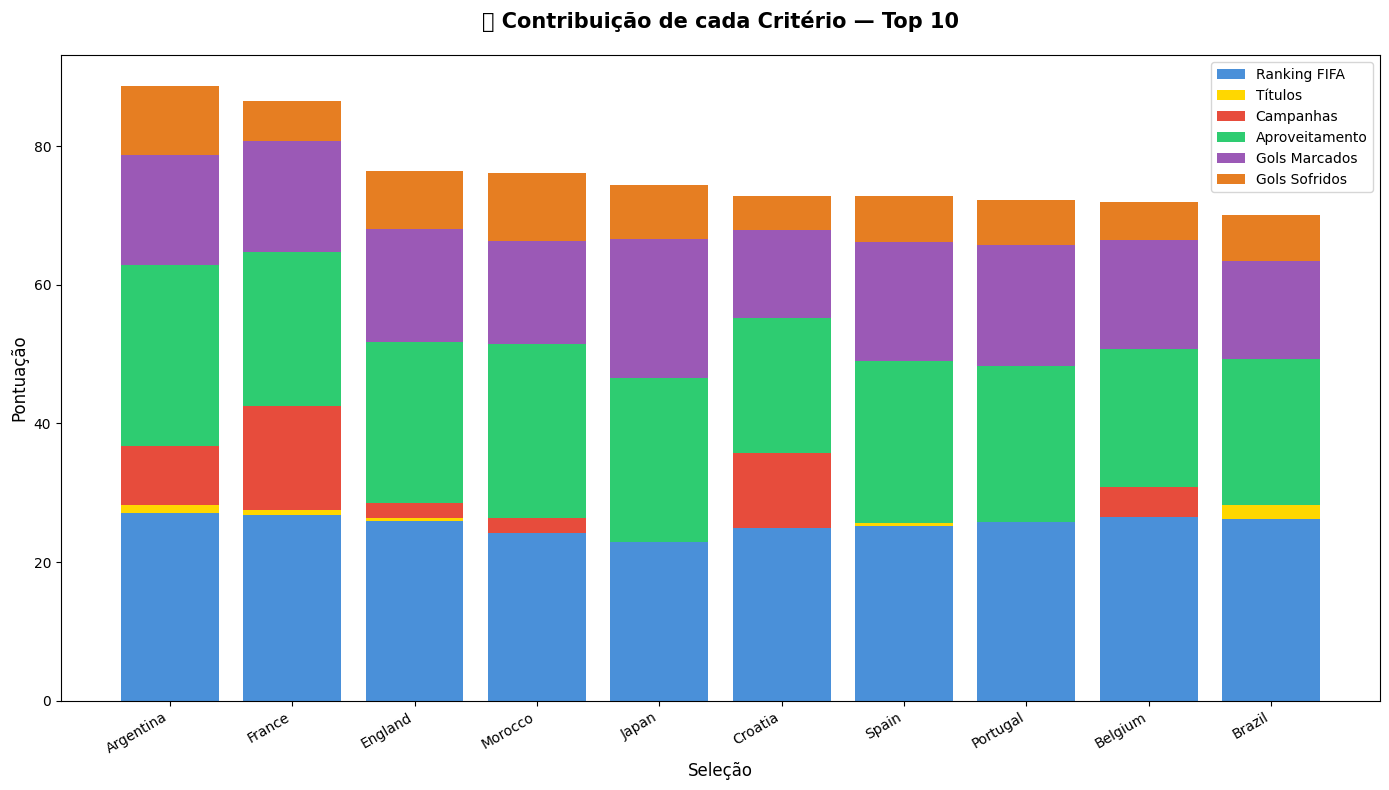

✅ Gráfico salvo em images/contribuicao_criterios.png


In [4]:
# Top 10 seleções
top10 = df_final.head(10)

# Calculando contribuição real de cada critério
top10 = top10.copy()
top10['contrib_ranking']       = top10['nota_ranking']        * 0.27
top10['contrib_titulos']       = top10['nota_titulos']        * 0.02
top10['contrib_campanha']      = top10['nota_campanha']       * 0.15
top10['contrib_aproveitamento']= top10['nota_aproveitamento'] * 0.26
top10['contrib_gols_marcados'] = top10['nota_gols_marcados']  * 0.20
top10['contrib_gols_sofridos'] = top10['nota_gols_sofridos']  * 0.10

# Configurando o gráfico
contribuicoes = ['contrib_ranking', 'contrib_titulos', 'contrib_campanha',
                 'contrib_aproveitamento', 'contrib_gols_marcados', 'contrib_gols_sofridos']
labels = ['Ranking FIFA', 'Títulos', 'Campanhas', 'Aproveitamento', 'Gols Marcados', 'Gols Sofridos']
cores = ['#4A90D9', '#FFD700', '#E74C3C', '#2ECC71', '#9B59B6', '#E67E22']

fig, ax = plt.subplots(figsize=(14, 8))

bottom = np.zeros(len(top10))
for i, (col, label, cor) in enumerate(zip(contribuicoes, labels, cores)):
    valores = top10[col].values
    ax.bar(top10['country_full'], valores, bottom=bottom, label=label, color=cor)
    bottom += valores

ax.set_title('📊 Contribuição de cada Critério — Top 10', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Seleção', fontsize=12)
ax.set_ylabel('Pontuação', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../images/contribuicao_criterios.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico salvo em images/contribuicao_criterios.png")